### Chain of Thoughts with RAG

A Chain of Thought is simply a sequence of these intermediate steps that bridge the gap between the question and the answer.

- Step1: Decompose the user question ->sub steps(Reason)
- Step 2: Retrieve docs per step
- Step 3: Combine context(Observe)
- Step 4: Final Answer geneartion

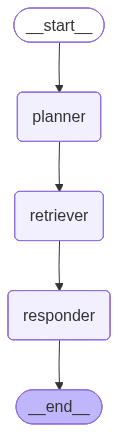

In [1]:
import os
from  typing import List , Annotated, TypedDict, Sequence, Literal
from pydantic import BaseModel, Field

from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from  typing import List , Annotated, TypedDict, Sequence, Literal
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate


from langchain_groq import ChatGroq

/tmp/ipykernel_25839/4119248320.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.vectorstores import FAISS
/workspaces/AgenticAI/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
import os
from dotenv import load_dotenv
load_dotenv()




True

In [3]:
# Initialize global ChatGroq model
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = ChatGroq(model="qwen/qwen3-32b")


In [4]:
### 1. Document Processing

urls=[
    "https://docs.langchain.com/oss/python/langchain/overview",
    "https://docs.langchain.com/oss/python/integrations/providers/overview"
]

loaders = [WebBaseLoader(url) for url in urls]

docs=[]

for loader in loaders:
    docs.extend(loader.load())

docs

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langchain/overview', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain provides create_agent: a minimal, highly configurable agent harness. Compose exactly the agent your use case needs from model, tools, prompt, and middleware.', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentDocs by LangChain home pageBuildSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewOverviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryEvent streamingStreamingStructured outputMiddlewareOverviewPrebuilt middlewareCustom middlewareFrontendOverviewPatternsIntegrations

In [5]:
## 2. Recursive character txt splitter as vector store

splitter =RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
split_docs = splitter.split_documents(docs)

embedding = OpenAIEmbeddings()

vectorstore = FAISS.from_documents(split_docs, embedding)
retriever= vectorstore.as_retriever()

retriever.invoke("what is reward function") # test the retriever

[Document(id='09f6e35e-3873-4ae1-bf1f-6098afeada4c', metadata={'source': 'https://docs.langchain.com/oss/python/integrations/providers/overview', 'title': 'LangChain Python integrations - Docs by LangChain', 'description': 'Integrate with providers using LangChain Python.', 'language': 'en'}, page_content='A provider is a company or platform that hosts AI models and exposes them through an API (e.g., OpenAI, Anthropic, Google). Many providers have a dedicated langchain-<provider> package that implements one or more of LangChain’s standard interfaces—chat models, embedding models, vector stores, and more—giving you a consistent API regardless of the underlying provider. Install the package, pick a model name, and swap providers without changing your code.'),
 Document(id='474b9588-dca4-4015-b869-606f19037bb6', metadata={'source': 'https://docs.langchain.com/oss/python/integrations/providers/overview', 'title': 'LangChain Python integrations - Docs by LangChain', 'description': 'Integrat

In [6]:
from pydantic import BaseModel, Field
from typing import List, Dict

class RAGCoTState(BaseModel):
    question: str
    sub_steps: List[str] = Field(default_factory=list)
    retrieved_docs: Dict[str, List[str]] = Field(default_factory=dict)
    final_answer: str = ""

In [7]:
# Node Creation

# 1 . Decompose the user question into su steps



def plan_steps(state: RAGCoTState) -> RAGCoTState:
    prompt = f"""
Break the question into 2-3 reasoning steps.

Return only the steps.
Do not include <think>.
Do not include explanation.

Question:
{state.question}
"""

    response = llm.invoke(prompt).content

    state.sub_steps = [
        line.strip("123456789.- ").strip()
        for line in response.split("\n")
        if line.strip() and "<think>" not in line.lower()
    ]

    return state

In [8]:
# Retrieve for each step

def retrieve_per_step(state: RAGCoTState) -> RAGCoTState:

    retrieved_context = {}

    for step in state.sub_steps:

        docs = retriever.invoke(step)

        retrieved_context[step] = [
            doc.page_content
            for doc in docs
        ]

    state.retrieved_docs = retrieved_context

    return state

In [9]:
def generate_answer(state: RAGCoTState) -> RAGCoTState:
    context = ""

    for step, docs in state.retrieved_docs.items():
        context += f"\nReasoning Step: {step}\n"
        for doc in docs:
            context += f"- {doc}\n"

    prompt = f"""
You are a reasoning-based RAG assistant.

Use only the retrieved context to answer.

User Question:
{state.question}

Reasoning Steps:
{state.sub_steps}

Retrieved Documents:
{context}

Instructions:
- Use the reasoning steps as a guide.
- Use only retrieved documents.
- Do not show hidden chain-of-thought.
- Give a short reasoning summary and final answer.
- If context is missing, say what is missing.

Final Answer:
"""

    response = llm.invoke(prompt).content

    state.final_answer = response  

    return state

In [10]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(RAGCoTState)

builder.add_node("planner", plan_steps)
builder.add_node("retriever", retrieve_per_step)
builder.add_node("responder", generate_answer)

builder.add_edge(START, "planner")
builder.add_edge("planner", "retriever")
builder.add_edge("retriever", "responder")
builder.add_edge("responder", END)

graph = builder.compile()

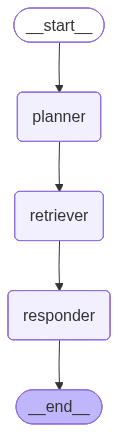

In [11]:
# View the graph
from IPython.display import Image, display

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [12]:
complex_question = """
What is LangGraph and how is it different from LangChain?
"""

initial_state = RAGCoTState(
    question=complex_question
)


result = graph.invoke({
    "question": complex_question
})
print("\n========== QUESTION ==========")
print(result["question"])

print("\n========== PLANNER STEPS ==========")
for i, step in enumerate(result["sub_steps"], start=1):
    print(f"{i}. {step}")

print("\n========== RETRIEVED DOCS ==========")
for step, docs in result["retrieved_docs"].items():
    print(f"\n--- Step: {step} ---")
    for i, doc in enumerate(docs, start=1):
        print(f"\nDoc {i}:")
        print(doc[:1000])

print("\n========== FINAL ANSWER ==========")
print(result["final_answer"])


========== QUESTION ==========

What is LangGraph and how is it different from LangChain?


========== PLANNER STEPS ==========
1. </think>
2. Define what LangGraph is and its primary purpose
3. Define what LangChain is and its primary purpose
4. Highlight key differences in their design, functionality, and use cases

========== RETRIEVED DOCS ==========

--- Step: </think> ---

Doc 1:
startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryEvent streamingStreamingStructured outputMiddlewareOverviewPrebuilt middlewareCustom middlewareFrontendOverviewPatternsIntegrationsAdvanced usageGuardrailsRuntimeContext engineeringModel Context Protocol (MCP)Human-in-the-loopMulti-agentRetrievalLong-term memoryAgent developmentLangSmith StudioTestAgent Chat UIDeploy with LangSmithDeploymentObservabilityOn this page Create an agent Core

Doc 2:
& embedding models, tools & toolkits, document loaders, vector stores, and more.

Doc 3:
combining deterministic